In [1]:
import os
import sys
sys.path.append(os.path.abspath("vanguard/notebooks"))
from skeleton3d import skeletonize3d, _OFFSETS_3D
from skeleton3d_visuals import edges_to_segments, plot_skeleton3d, plot_skeleton_projections
 
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

import plotly.graph_objects as go


### Step 1. Import image. 
The image we will be using as input comes from Step 3 of the Prediction Workflow ipynb. The `final_image` has three channels (first dimension), which are probabilities that a given pixel is fibroglandular tissue, blood vessel, or neither. Each channel is represented as a three-dimensional array with probabilities. 

In [2]:
final_image = np.load("tries/sample.npy")
print(f"Probabilities should be between 0 and 1")
print(np.min(final_image), np.max(final_image))
print(f"The sum of the three channels must be close to 1")
print(np.isclose(np.sum(final_image, axis=0), 1, rtol=0.002).all())

Probabilities should be between 0 and 1
0.0 1.0
The sum of the three channels must be close to 1
True


### Step 2. Keep blood vessels
We will only use channel 1 of each image. Channel 1 represents probabilities of each voxel being part of a blood vessel.

In [3]:
vessels = final_image[1]

In [4]:
print("Shape:", vessels.shape)
print("Data type:", vessels.dtype)
print("Min:", np.min(vessels))
print("Max:", np.max(vessels))
print("Unique values (sample):", np.unique(vessels)[:10])

Shape: (448, 448, 160)
Data type: float16
Min: 0.0
Max: 1.0
Unique values (sample): [0.0e+00 6.0e-08 1.2e-07 1.8e-07 2.4e-07 3.0e-07 3.6e-07 4.2e-07 4.8e-07
 5.4e-07]


### Step 3. Skeletonize 3D image
The next step consists on skeletonize a 3D image using skeletonize3d() and a predefined probability threshold.

In [5]:
skeleton = skeletonize3d(vessels, threshold=0.90)

In [6]:
print("Shape:", skeleton.shape)
print("Data type:", skeleton.dtype)
print("Min:", np.min(skeleton))
print("Max:", np.max(skeleton))
print("Unique values (sample):", np.unique(skeleton)[:10])

Shape: (448, 448, 160)
Data type: uint32
Min: 0
Max: 37748768
Unique values (sample): [ 0  1  2  4  8 12 16 32 40 64]


### Step 4. Visualize the output

In [7]:
segments = edges_to_segments(skeleton)
print(f"{len(segments)} line segments extracted")

3499 line segments extracted


In [8]:
fig = plot_skeleton3d(segments)
fig.show()

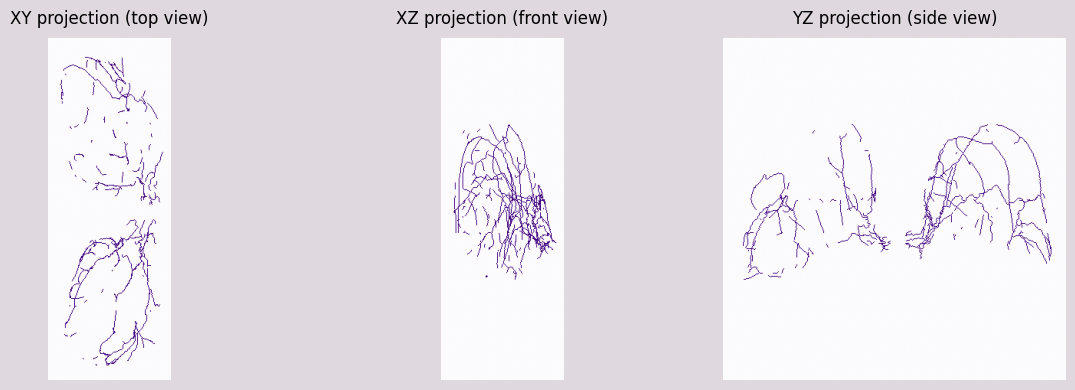

In [9]:
plot_skeleton_projections(skeleton)